In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import linear_model

## Voorspellen van bloeddruk op basis van gewicht en leeftijd

In [2]:
# Inlezen van de dataset 'bloeddruk.csv'
data_bd = pd.read_csv('data/bloeddruk.csv')

In [3]:
# Dimensie van de dataset
data_bd.shape

(11, 3)

In [5]:
data_bd

,leeftijd,gewicht,bloeddruk
0,52,78,136
1,59,83,143
2,67,88,153
3,73,96,162
4,64,89,161
5,74,103,171
6,54,85,137
7,61,85,149
8,65,94,162
9,46,76,128


In [6]:
data_bd.describe

<bound method NDFrame.describe of     leeftijd  gewicht  bloeddruk
0         52       78        136
1         59       83        143
2         67       88        153
3         73       96        162
4         64       89        161
5         74      103        171
6         54       85        137
7         61       85        149
8         65       94        162
9         46       76        128
10        72       98        166>

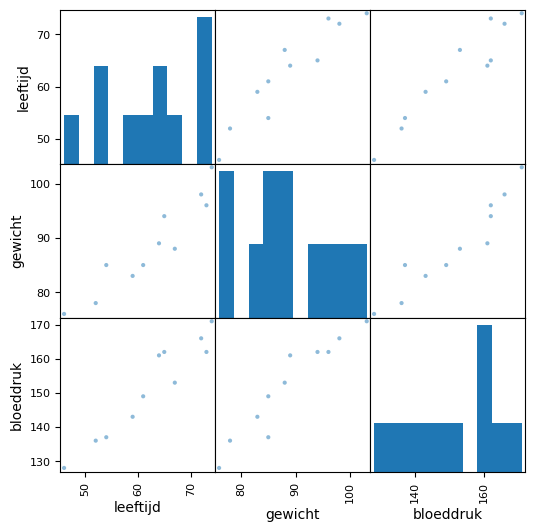

In [7]:
# scatterplot tussen gewicht en bloeddruk
pd.plotting.scatter_matrix(data_bd, figsize=(6, 6))
plt.show()

In [8]:
# onderlinge correlatiecoefficienten
data_corr=data_bd.corr()
print(data_bd.corr())

           leeftijd   gewicht  bloeddruk
leeftijd   1.000000  0.936927   0.955477
gewicht    0.936927  1.000000   0.947494
bloeddruk  0.955477  0.947494   1.000000


## Linear Regression

In [9]:
# Opsplitsen in features (X) en target (y)
X = data_bd[['leeftijd', 'gewicht']]
y = data_bd['bloeddruk']

In [10]:
# LinearRegression model instantieren
reg = linear_model.LinearRegression()

In [11]:
# LR model fitten op leeftijd en bloeddruk (niet gewicht)
leeftijden = X[['leeftijd']]
print(leeftijden)

    leeftijd
0         52
1         59
2         67
3         73
4         64
5         74
6         54
7         61
8         65
9         46
10        72


In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression() 
model.fit(leeftijden, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


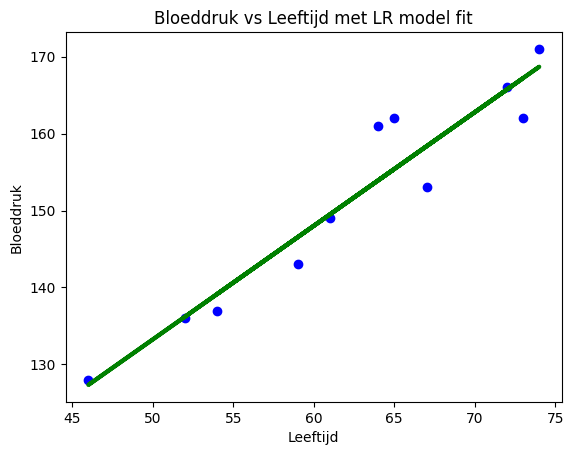

In [13]:
# scatter plot met bloeddruk ifv leeftijd + LR model fit
plt.scatter(leeftijden, y, color='blue')
plt.plot(leeftijden, model.predict(leeftijden), color='green', linewidth=3)
plt.xlabel('Leeftijd')
plt.ylabel('Bloeddruk')
plt.title('Bloeddruk vs Leeftijd met LR model fit')
plt.show()

In [ ]:
# model coefficients:
print('theta_1 = ', model.coef_) # \hat \theta_1
print('theta_0 = ', model.intercept_) # \hat \theta_0'

theta_1 =  [1.47680018]
theta_0 =  59.40347997373604


In [15]:
# Voorspel de bloeddruk van een persoon met een leeftijd van 72 jaar
# np.array([[72]]) maakt een 2D array met één rij en één kolom want we willen 1 sample met 1 feature laten voorspellen,
# de predict functie verwacht een 2D array als input. 
test_predictions = model.predict(np.array([[72]]))
print(test_predictions)

[165.73309258]


c:\Users\Cursist\DataScienceCourse\DS_Projects\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
# Voorspel de bloeddruk van iemand met een leeftijd van 24 jaar en een gewicht van 86kg
X = data_bd[['leeftijd', 'gewicht']].values 
y = data_bd[['bloeddruk']].values 
model_mv = LinearRegression() 
model_mv.fit(X, y)
test_predictions_mv = model_mv.predict(np.array([[24, 120]]))
print(test_predictions_mv)

[[141.14015927]]


In [18]:
print('theta_1 = ', model_mv.coef_) # \hat \theta_1
print('theta_0 = ', model_mv.intercept_)

theta_1 =  [[0.85708344 0.71619724]]
theta_0 =  [34.62648848]


## Model performantie evalueren

In [19]:
from sklearn.model_selection import train_test_split

# doe train-test split met random_state = 42, test_size = 0.2 (train_size=0.8)
X = data_bd[['leeftijd','gewicht']].values
y = data_bd['bloeddruk'].values
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, random_state= 42)

In [20]:
# fit on train + predict on testset
model_mv2 = LinearRegression() 
model_mv2.fit(X_train, y_train)
y_pred = model_mv2.predict(X_test)

In [ ]:
# calculate MAE, MSE, RMSE and MAPE
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error

# Calculate and print R^2 score.
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")

# Calculate and print MSE.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")

# Calculate and print RMSE.
rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")

# MAPE
mape = mean_absolute_percentage_error(y_test,y_pred)
print(f"Mean absolute percentage error: {mape:.4f}%")

# Calculate and print MAE.
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean absolute error: {mae:.4f}")

R-squared: 0.9935
Mean squared error: 2.2582
Root mean squared error: 1.5027
Mean absolute percentage error: 0.0083
Mean absolute error: 1.2673


✔ MAE is easy to interpret but does not punish large errors heavily.

✔ MSE penalizes large errors, making it useful when large deviations matter (suitable when large deviations should be avoided.)

✔ RMSE is more interpretable than MSE but still gives weight to large errors (useful when we want to consider both small and large errors)

✔ R² Score (aka Coefficient of Determination) tells how well the model explains the data variance.

NB. Lower MAE, (R)MSE = better model performance; R² close to 1 → Model explains most of the variability (good fit), R² close to 0 → Model is not better than a simple mean prediction, Negative R² → Model is worse than a random guess.

(cfr. https://medium.com/@srivastavashivansh8922/evaluating-model-performance-understanding-mae-mse-rmse-and-r%C2%B2-score-5516e10fe8d6)